# Logistic Regression Credit Risk Baseline

## Objective

This notebook builds an interpretable logistic regression baseline for predicting repayment difficulty.

The objectives are to:

1. Reproduce the same train/test split and feature engineering workflow
2. Train an unweighted logistic regression baseline
3. Train a class-weighted logistic regression model
4. Compare ranking and classification performance
5. Evaluate probability calibration
6. Analyze decision thresholds
7. Interpret model coefficients

In [4]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

In [5]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.feature_engineering import (
    INITIAL_FEATURES,
    create_domain_features,
)

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
MODEL_DIR = PROJECT_ROOT / "models"

TRAIN_PATH = RAW_DATA_DIR / "application_train.csv"
PREPROCESSOR_PATH = MODEL_DIR / "feature_preprocessor.joblib"

print("Project root:", PROJECT_ROOT)
print("Training data exists:", TRAIN_PATH.exists())
print("Preprocessor exists:", PREPROCESSOR_PATH.exists())

Project root: /Users/hxxy/Desktop/找工/credit-risk-decisioning
Training data exists: True
Preprocessor exists: True


## 2. Data Loading and Train/Test Split

The same split configuration used in the feature-engineering notebook is reproduced here to ensure that the fitted preprocessor and model evaluation use the same applicants.

In [6]:
df = pd.read_csv(TRAIN_PATH)

X = df.drop(columns=["TARGET"])
y = df["TARGET"].astype("int8")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training target rate:", y_train.mean())
print("Test target rate:", y_test.mean())

Training shape: (246008, 121)
Test shape: (61503, 121)
Training target rate: 0.08072908198107379
Test target rate: 0.08072776937710356


In [7]:
assert len(X_train) + len(X_test) == len(df)
assert set(X_train.index).isdisjoint(set(X_test.index))
assert abs(y_train.mean() - y_test.mean()) < 0.001

## 3. Feature Preparation

Applicant IDs are retained for result tracking but excluded from model features. The same initial feature scope and domain feature-engineering function from Notebook 04 are reused.

In [8]:
train_ids = X_train["SK_ID_CURR"].copy()
test_ids = X_test["SK_ID_CURR"].copy()

X_train = X_train.drop(columns=["SK_ID_CURR"])
X_test = X_test.drop(columns=["SK_ID_CURR"])

missing_initial_features = [
    col
    for col in INITIAL_FEATURES
    if col not in X_train.columns
]

if missing_initial_features:
    raise ValueError(
        f"Initial features missing from dataset: {missing_initial_features}"
    )

X_train_fe = X_train[INITIAL_FEATURES].copy()
X_test_fe = X_test[INITIAL_FEATURES].copy()

X_train_fe = create_domain_features(X_train_fe)
X_test_fe = create_domain_features(X_test_fe)

print("Feature-engineered training shape:", X_train_fe.shape)
print("Feature-engineered test shape:", X_test_fe.shape)

Feature-engineered training shape: (246008, 51)
Feature-engineered test shape: (61503, 51)


In [9]:
assert list(X_train_fe.columns) == list(X_test_fe.columns)

numeric_train = X_train_fe.select_dtypes(include=["number"])
numeric_test = X_test_fe.select_dtypes(include=["number"])

assert np.isinf(numeric_train).sum().sum() == 0
assert np.isinf(numeric_test).sum().sum() == 0

## 4. Apply the Fitted Preprocessor

The preprocessor fitted on the training split in Notebook 04 is loaded and applied without refitting. This preserves the learned medians, scaling parameters, and one-hot category definitions.

In [10]:
preprocessor = joblib.load(PREPROCESSOR_PATH)

X_train_processed = preprocessor.transform(X_train_fe)
X_test_processed = preprocessor.transform(X_test_fe)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (246008, 178)
Processed test shape: (61503, 178)


In [11]:
assert X_train_processed.shape[0] == len(y_train)
assert X_test_processed.shape[0] == len(y_test)
assert X_train_processed.shape[1] == X_test_processed.shape[1]

## 5. Unweighted Logistic Regression Baseline

The first model uses standard logistic regression without class weighting. This establishes a reference point before applying imbalance-aware training.

In [12]:
unweighted_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42,
)

unweighted_model.fit(
    X_train_processed,
    y_train,
)

/Users/hxxy/Desktop/找工/credit-risk-decisioning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-

In [13]:
unweighted_train_probability = (
    unweighted_model.predict_proba(
        X_train_processed
    )[:, 1]
)

unweighted_test_probability = (
    unweighted_model.predict_proba(
        X_test_processed
    )[:, 1]
)

unweighted_test_prediction = (
    unweighted_model.predict(
        X_test_processed
    )
)

In [14]:
unweighted_train_roc_auc = roc_auc_score(
    y_train,
    unweighted_train_probability,
)

unweighted_test_roc_auc = roc_auc_score(
    y_test,
    unweighted_test_probability,
)

unweighted_test_pr_auc = average_precision_score(
    y_test,
    unweighted_test_probability,
)

print(
    "Training ROC-AUC:",
    round(unweighted_train_roc_auc, 4),
)

print(
    "Test ROC-AUC:",
    round(unweighted_test_roc_auc, 4),
)

print(
    "Test PR-AUC:",
    round(unweighted_test_pr_auc, 4),
)

print("\nClassification report at threshold 0.50:")
print(
    classification_report(
        y_test,
        unweighted_test_prediction,
        digits=4,
    )
)

Training ROC-AUC: 0.75
Test ROC-AUC: 0.7495
Test PR-AUC: 0.2372

Classification report at threshold 0.50:
              precision    recall  f1-score   support

           0     0.9199    0.9994    0.9580     56538
           1     0.5949    0.0095    0.0186      4965

    accuracy                         0.9195     61503
   macro avg     0.7574    0.5045    0.4883     61503
weighted avg     0.8937    0.9195    0.8822     61503



In [15]:
unweighted_confusion_matrix = confusion_matrix(
    y_test,
    unweighted_test_prediction,
)

unweighted_confusion_matrix_df = pd.DataFrame(
    unweighted_confusion_matrix,
    index=[
        "Actual 0",
        "Actual 1",
    ],
    columns=[
        "Predicted 0",
        "Predicted 1",
    ],
)

unweighted_confusion_matrix_df

,Predicted 0,Predicted 1
Actual 0,56506,32
Actual 1,4918,47


## 6. Class-Weighted Logistic Regression

Because repayment difficulty is the minority class, the second model uses
`class_weight="balanced"` to assign a larger loss to misclassified
high-risk applicants.

This does not create synthetic observations. It changes the contribution
of each class during model training.

In [16]:
balanced_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)

balanced_model.fit(
    X_train_processed,
    y_train,
)

/Users/hxxy/Desktop/找工/credit-risk-decisioning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in versi

In [17]:
balanced_train_probability = (
    balanced_model.predict_proba(
        X_train_processed
    )[:, 1]
)

balanced_test_probability = (
    balanced_model.predict_proba(
        X_test_processed
    )[:, 1]
)

balanced_test_prediction = (
    balanced_model.predict(
        X_test_processed
    )
)

In [18]:
balanced_train_roc_auc = roc_auc_score(
    y_train,
    balanced_train_probability,
)

balanced_test_roc_auc = roc_auc_score(
    y_test,
    balanced_test_probability,
)

balanced_test_pr_auc = average_precision_score(
    y_test,
    balanced_test_probability,
)

print(
    "Training ROC-AUC:",
    round(balanced_train_roc_auc, 4),
)

print(
    "Test ROC-AUC:",
    round(balanced_test_roc_auc, 4),
)

print(
    "Test PR-AUC:",
    round(balanced_test_pr_auc, 4),
)

print("\nClassification report at threshold 0.50:")

print(
    classification_report(
        y_test,
        balanced_test_prediction,
        digits=4,
    )
)

Training ROC-AUC: 0.7502
Test ROC-AUC: 0.7495
Test PR-AUC: 0.2351

Classification report at threshold 0.50:
              precision    recall  f1-score   support

           0     0.9607    0.6875    0.8014     56538
           1     0.1604    0.6800    0.2596      4965

    accuracy                         0.6869     61503
   macro avg     0.5606    0.6837    0.5305     61503
weighted avg     0.8961    0.6869    0.7577     61503



In [19]:
balanced_confusion_matrix = confusion_matrix(
    y_test,
    balanced_test_prediction,
)

balanced_confusion_matrix_df = pd.DataFrame(
    balanced_confusion_matrix,
    index=[
        "Actual 0",
        "Actual 1",
    ],
    columns=[
        "Predicted 0",
        "Predicted 1",
    ],
)

balanced_confusion_matrix_df

,Predicted 0,Predicted 1
Actual 0,38868,17670
Actual 1,1589,3376


In [20]:
model_comparison = pd.DataFrame({
    "Model": [
        "Unweighted Logistic Regression",
        "Balanced Logistic Regression",
    ],
    "Train ROC-AUC": [
        unweighted_train_roc_auc,
        balanced_train_roc_auc,
    ],
    "Test ROC-AUC": [
        unweighted_test_roc_auc,
        balanced_test_roc_auc,
    ],
    "Test PR-AUC": [
        unweighted_test_pr_auc,
        balanced_test_pr_auc,
    ],
})

model_comparison.round(4)

,Model,Train ROC-AUC,Test ROC-AUC,Test PR-AUC
0,Unweighted Logistic Regression,0.7500,0.7495,0.2372
1,Balanced Logistic Regression,0.7502,0.7495,0.2351


In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)

classification_comparison = pd.DataFrame({
    "Model": [
        "Unweighted",
        "Balanced",
    ],
    "Precision for TARGET=1": [
        precision_score(
            y_test,
            unweighted_test_prediction,
            zero_division=0,
        ),
        precision_score(
            y_test,
            balanced_test_prediction,
            zero_division=0,
        ),
    ],
    "Recall for TARGET=1": [
        recall_score(
            y_test,
            unweighted_test_prediction,
            zero_division=0,
        ),
        recall_score(
            y_test,
            balanced_test_prediction,
            zero_division=0,
        ),
    ],
    "F1 for TARGET=1": [
        f1_score(
            y_test,
            unweighted_test_prediction,
            zero_division=0,
        ),
        f1_score(
            y_test,
            balanced_test_prediction,
            zero_division=0,
        ),
    ],
})

classification_comparison.round(4)

,Model,Precision for TARGET=1,Recall for TARGET=1,F1 for TARGET=1
0,Unweighted,0.5949,0.0095,0.0186
1,Balanced,0.1604,0.6800,0.2596


## 7. Threshold Analysis

The default threshold of 0.50 is not necessarily appropriate for an
imbalanced credit-risk problem.

Different thresholds produce different trade-offs between:

- identifying more high-risk applicants,
- incorrectly flagging low-risk applicants,
- approval volume,
- and portfolio risk.

The following analysis evaluates several candidate thresholds using the
balanced logistic regression model.

In [23]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


def evaluate_thresholds(
    y_true: pd.Series,
    probabilities: np.ndarray,
    thresholds: list[float],
) -> pd.DataFrame:
    rows = []

    for threshold in thresholds:
        predictions = (
            probabilities >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions,
        ).ravel()

        predicted_positive_rate = (
            predictions.mean()
        )

        false_positive_rate = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

        rows.append({
            "threshold": threshold,
            "precision": precision_score(
                y_true,
                predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_true,
                predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                y_true,
                predictions,
                zero_division=0,
            ),
            "accuracy": accuracy_score(
                y_true,
                predictions,
            ),
            "false_positive_rate": false_positive_rate,
            "predicted_high_risk_rate": (
                predicted_positive_rate
            ),
            "true_negatives": tn,
            "false_positives": fp,
            "false_negatives": fn,
            "true_positives": tp,
        })

    return pd.DataFrame(rows)

In [24]:
candidate_thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
]

balanced_threshold_results = evaluate_thresholds(
    y_true=y_test,
    probabilities=balanced_test_probability,
    thresholds=candidate_thresholds,
)

balanced_threshold_results.round(4)

,threshold,precision,recall,f1,accuracy,false_positive_rate,predicted_high_risk_rate,true_negatives,false_positives,false_negatives,true_positives
0,0.20,0.0920,0.9696,0.1681,0.2253,0.8401,0.8505,9041,47497,151,4814
1,0.25,0.0995,0.9444,0.1800,0.3054,0.7507,0.7663,14095,42443,276,4689
2,0.30,0.1086,0.9074,0.1940,0.3913,0.6541,0.6745,19559,36979,460,4505
3,0.35,0.1191,0.8612,0.2093,0.4748,0.5592,0.5835,24924,31614,689,4276
4,0.40,0.1318,0.8117,0.2267,0.5530,0.4697,0.4973,29981,26557,935,4030
5,0.45,0.1454,0.7492,0.2435,0.6242,0.3868,0.4161,34669,21869,1245,3720
6,0.50,0.1604,0.6800,0.2596,0.6869,0.3125,0.3422,38868,17670,1589,3376
7,0.55,0.1786,0.6075,0.2761,0.7428,0.2453,0.2745,42669,13869,1949,3016
8,0.60,0.2004,0.5269,0.2904,0.7921,0.1846,0.2122,46101,10437,2349,2616
9,0.65,0.2268,0.4411,0.2995,0.8335,0.1321,0.1570,49070,7468,2775,2190


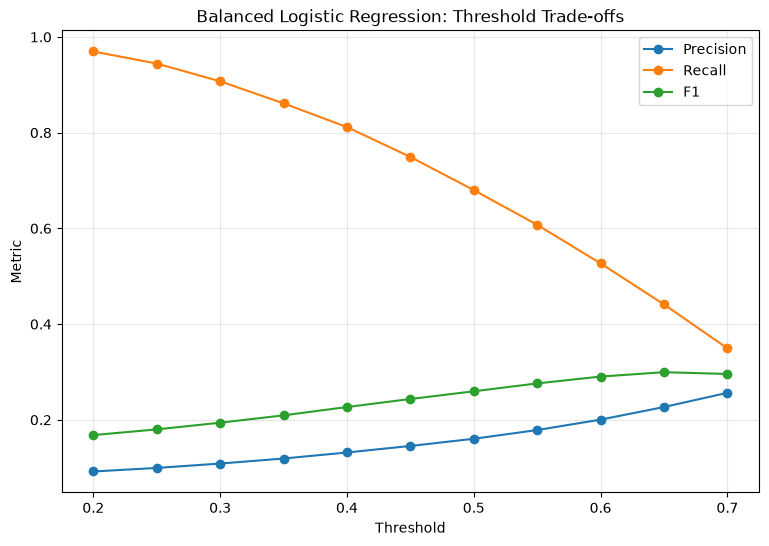

In [25]:
plt.figure(figsize=(9, 6))

plt.plot(
    balanced_threshold_results["threshold"],
    balanced_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    balanced_threshold_results["threshold"],
    balanced_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    balanced_threshold_results["threshold"],
    balanced_threshold_results["f1"],
    marker="o",
    label="F1",
)

plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title(
    "Balanced Logistic Regression: "
    "Threshold Trade-offs"
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [26]:
best_f1_row = (
    balanced_threshold_results
    .sort_values(
        by="f1",
        ascending=False,
    )
    .iloc[0]
)

best_f1_row

threshold                       0.650000
precision                       0.226755
recall                          0.441088
f1                              0.299528
accuracy                        0.833455
false_positive_rate             0.132088
predicted_high_risk_rate        0.157033
true_negatives              49070.000000
false_positives              7468.000000
false_negatives              2775.000000
true_positives               2190.000000
Name: 9, dtype: float64

In [27]:
fine_thresholds = np.arange(
    0.10,
    0.81,
    0.01,
)

fine_threshold_results = evaluate_thresholds(
    y_true=y_test,
    probabilities=balanced_test_probability,
    thresholds=fine_thresholds.tolist(),
)

best_f1_result = (
    fine_threshold_results
    .sort_values(
        by="f1",
        ascending=False,
    )
    .iloc[0]
)

best_f1_result

threshold                       0.670000
precision                       0.239777
recall                          0.407452
f1                              0.301895
accuracy                        0.847877
false_positive_rate             0.113446
predicted_high_risk_rate        0.137180
true_negatives              50124.000000
false_positives              6414.000000
false_negatives              2942.000000
true_positives               2023.000000
Name: 57, dtype: float64

In [28]:
business_candidate_thresholds = (
    fine_threshold_results[
        fine_threshold_results["recall"].between(
            0.50,
            0.75,
        )
    ]
    .sort_values(
        by="precision",
        ascending=False,
    )
)

business_candidate_thresholds.head(10).round(4)

,threshold,precision,recall,f1,accuracy,false_positive_rate,predicted_high_risk_rate,true_negatives,false_positives,false_negatives,true_positives
51,0.61,0.2050,0.5092,0.2923,0.8009,0.1734,0.2005,46732,9806,2437,2528
50,0.60,0.2004,0.5269,0.2904,0.7921,0.1846,0.2122,46101,10437,2349,2616
49,0.59,0.1949,0.5420,0.2867,0.7823,0.1966,0.2245,45424,11114,2274,2691
48,0.58,0.1903,0.5577,0.2838,0.7728,0.2083,0.2365,44760,11778,2196,2769
47,0.57,0.1860,0.5730,0.2808,0.7631,0.2203,0.2487,44085,12453,2120,2845
46,0.56,0.1826,0.5913,0.2790,0.7532,0.2325,0.2615,43391,13147,2029,2936
45,0.55,0.1786,0.6075,0.2761,0.7428,0.2453,0.2745,42669,13869,1949,3016
44,0.54,0.1750,0.6232,0.2733,0.7325,0.2580,0.2874,41954,14584,1871,3094
43,0.53,0.1712,0.6379,0.2699,0.7214,0.2712,0.3008,41204,15334,1798,3167
42,0.52,0.1670,0.6506,0.2658,0.7099,0.2849,0.3144,40432,16106,1735,3230


In [29]:
LOW_RISK_CUTOFF = 0.35
HIGH_RISK_CUTOFF = 0.60


def assign_risk_band(
    probability: float,
) -> str:
    if probability < LOW_RISK_CUTOFF:
        return "Approve"
    elif probability < HIGH_RISK_CUTOFF:
        return "Manual Review"
    else:
        return "Decline / High Risk"

In [34]:
test_decisions = pd.DataFrame({
    "SK_ID_CURR": test_ids.reset_index(drop=True),
    "TARGET": y_test.reset_index(drop=True),
    "PREDICTED_PROBABILITY": (
        balanced_test_probability
    ),
})

test_decisions["DECISION_BAND"] = (
    test_decisions[
        "PREDICTED_PROBABILITY"
    ]
    .apply(assign_risk_band)
)

test_decisions.head()

,SK_ID_CURR,TARGET,PREDICTED_PROBABILITY,DECISION_BAND
0,396899,0,0.466155,Manual Review
1,322041,0,0.344496,Approve
2,220127,0,0.804007,Decline / High Risk
3,251531,0,0.563713,Manual Review
4,345558,0,0.618928,Decline / High Risk


In [35]:
risk_band_summary = (
    test_decisions
    .groupby("DECISION_BAND")
    .agg(
        applicants=(
            "SK_ID_CURR",
            "count",
        ),
        default_rate=(
            "TARGET",
            "mean",
        ),
        average_predicted_risk=(
            "PREDICTED_PROBABILITY",
            "mean",
        ),
    )
)

risk_band_summary["portfolio_share"] = (
    risk_band_summary["applicants"]
    / len(test_decisions)
)

risk_band_summary.round(4)

,applicants,default_rate,average_predicted_risk,portfolio_share
DECISION_BAND,,,,
Approve,25613,0.0269,0.2284,0.4165
Decline / High Risk,13053,0.2004,0.7173,0.2122
Manual Review,22837,0.0727,0.4664,0.3713


## 8. Ranking Performance

ROC and precision-recall curves evaluate the model's ability to rank
high-risk applicants above lower-risk applicants across all possible
classification thresholds.

In [36]:
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

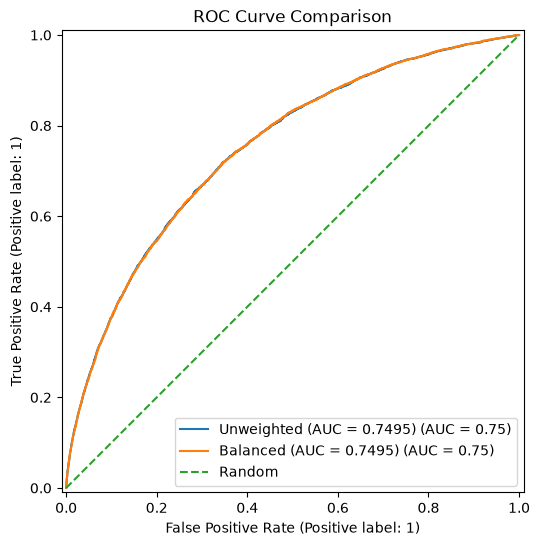

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    unweighted_test_probability,
    name=f"Unweighted (AUC = {unweighted_test_roc_auc:.4f})",
    ax=ax,
)

RocCurveDisplay.from_predictions(
    y_test,
    balanced_test_probability,
    name=f"Balanced (AUC = {balanced_test_roc_auc:.4f})",
    ax=ax,
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random",
)

ax.set_title("ROC Curve Comparison")
ax.legend()

plt.show()

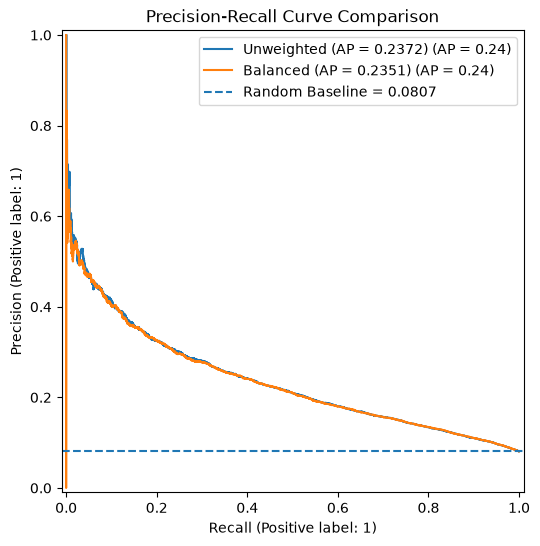

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    unweighted_test_probability,
    name=f"Unweighted (AP = {unweighted_test_pr_auc:.4f})",
    ax=ax,
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    balanced_test_probability,
    name=f"Balanced (AP = {balanced_test_pr_auc:.4f})",
    ax=ax,
)

ax.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Random Baseline = {y_test.mean():.4f}",
)

ax.set_title("Precision-Recall Curve Comparison")
ax.legend()

plt.show()

## 9. KS Statistic

The Kolmogorov-Smirnov statistic measures the maximum separation between
the cumulative score distributions of applicants with and without
repayment difficulty.

KS is commonly used in credit-risk model evaluation because it directly
measures the model's ability to separate higher-risk and lower-risk
applicants.

Thresholds derived from the test set are reported for diagnostic purposes
only and are not treated as final operational thresholds.

In [47]:
from sklearn.metrics import roc_curve


def calculate_ks(
    y_true: pd.Series,
    probabilities: np.ndarray,
) -> dict:
    """
    Calculate the maximum separation between the cumulative
    distributions of positive and negative observations.
    """
    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_true,
        probabilities,
    )

    ks_values = true_positive_rate - false_positive_rate
    best_index = np.argmax(ks_values)

    return {
        "ks_statistic": ks_values[best_index],
        "ks_threshold": thresholds[best_index],
        "true_positive_rate": true_positive_rate[best_index],
        "false_positive_rate": false_positive_rate[best_index],
    }

In [51]:
unweighted_ks = calculate_ks(
    y_test,
    unweighted_test_probability,
)

balanced_ks = calculate_ks(
    y_test,
    balanced_test_probability,
)

ks_comparison = pd.DataFrame({
    "Model": [
        "Unweighted Logistic Regression",
        "Balanced Logistic Regression",
    ],
    "KS Statistic": [
        unweighted_ks["ks_statistic"],
        balanced_ks["ks_statistic"],
    ],
    "Score Threshold at Maximum KS": [
        unweighted_ks["ks_threshold"],
        balanced_ks["ks_threshold"],
    ],
    "TPR at Maximum KS": [
        unweighted_ks["true_positive_rate"],
        balanced_ks["true_positive_rate"],
    ],
    "FPR at Maximum KS": [
        unweighted_ks["false_positive_rate"],
        balanced_ks["false_positive_rate"],
    ],
})

ks_comparison.round(4)

,Model,KS Statistic,Score Threshold at Maximum KS,TPR at Maximum KS,FPR at Maximum KS
0,Unweighted Logistic Regression,0.3727,0.0744,0.7178,0.3451
1,Balanced Logistic Regression,0.3714,0.4762,0.7178,0.3464


In [54]:
def plot_ks_curve(
    y_true: pd.Series,
    probabilities: np.ndarray,
    model_name: str,
) -> None:
    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_true,
        probabilities,
    )

    finite_mask = np.isfinite(thresholds)

    false_positive_rate = false_positive_rate[finite_mask]
    true_positive_rate = true_positive_rate[finite_mask]
    thresholds = thresholds[finite_mask]

    ks_values = true_positive_rate - false_positive_rate
    best_index = np.argmax(ks_values)

    plt.figure(figsize=(9, 6))

    plt.plot(
        thresholds,
        true_positive_rate,
        label="True Positive Rate",
    )

    plt.plot(
        thresholds,
        false_positive_rate,
        label="False Positive Rate",
    )

    plt.axvline(
        thresholds[best_index],
        linestyle="--",
        label=(
            f"Maximum KS = {ks_values[best_index]:.4f}"
        ),
    )

    plt.xlabel("Model Score Threshold")
    plt.ylabel("Rate")
    plt.title(f"KS Curve: {model_name}")
    plt.legend()
    plt.show()

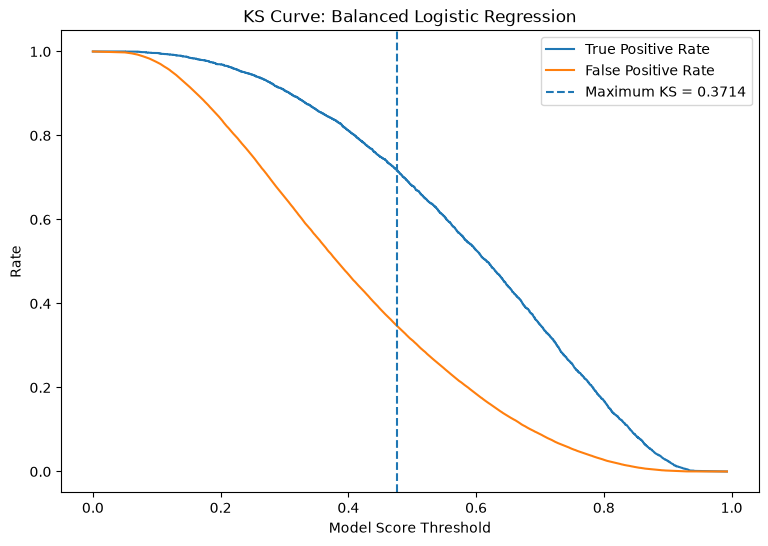

In [55]:
plot_ks_curve(
    y_true=y_test,
    probabilities=balanced_test_probability,
    model_name="Balanced Logistic Regression",
)

## 10. Probability Calibration

Ranking performance and probability calibration answer different questions.

- ROC-AUC and PR-AUC measure whether higher-risk applicants receive
  higher scores.
- Calibration measures whether predicted probabilities correspond to
  observed default rates.

Because `class_weight="balanced"` changes the effective class distribution
during training, the balanced model's raw probabilities should not be
interpreted directly as probabilities of default.

In [44]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

In [56]:
calibration_comparison = pd.DataFrame({
    "Model": [
        "Unweighted Logistic Regression",
        "Balanced Logistic Regression",
    ],
    "Mean Predicted Probability": [
        unweighted_test_probability.mean(),
        balanced_test_probability.mean(),
    ],
    "Observed Default Rate": [
        y_test.mean(),
        y_test.mean(),
    ],
    "Brier Score": [
        brier_score_loss(
            y_test,
            unweighted_test_probability,
        ),
        brier_score_loss(
            y_test,
            balanced_test_probability,
        ),
    ],
})

calibration_comparison.round(4)

,Model,Mean Predicted Probability,Observed Default Rate,Brier Score
0,Unweighted Logistic Regression,0.0805,0.0807,0.0682
1,Balanced Logistic Regression,0.4206,0.0807,0.2024


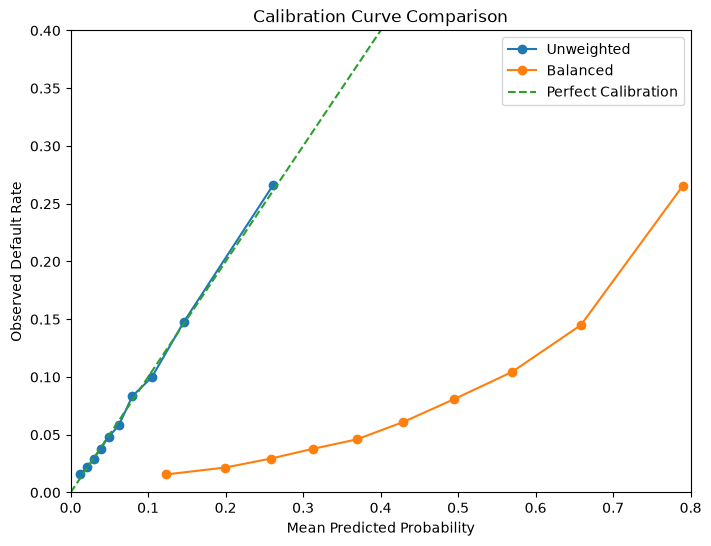

In [58]:
unweighted_fraction_positive, unweighted_mean_predicted = (
    calibration_curve(
        y_test,
        unweighted_test_probability,
        n_bins=10,
        strategy="quantile",
    )
)

balanced_fraction_positive, balanced_mean_predicted = (
    calibration_curve(
        y_test,
        balanced_test_probability,
        n_bins=10,
        strategy="quantile",
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    unweighted_mean_predicted,
    unweighted_fraction_positive,
    marker="o",
    label="Unweighted",
)

plt.plot(
    balanced_mean_predicted,
    balanced_fraction_positive,
    marker="o",
    label="Balanced",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration",
)

plt.xlim(0, 0.8)
plt.ylim(0, 0.4)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.show()

In [59]:
def create_calibration_table(
    y_true: pd.Series,
    probabilities: np.ndarray,
    n_bins: int = 10,
) -> pd.DataFrame:
    calibration_data = pd.DataFrame({
        "TARGET": y_true.reset_index(drop=True),
        "PREDICTED_PROBABILITY": probabilities,
    })

    calibration_data["RISK_DECILE"] = pd.qcut(
        calibration_data["PREDICTED_PROBABILITY"],
        q=n_bins,
        labels=False,
        duplicates="drop",
    ) + 1

    calibration_table = (
        calibration_data
        .groupby("RISK_DECILE")
        .agg(
            applicants=("TARGET", "size"),
            observed_default_rate=("TARGET", "mean"),
            average_predicted_probability=(
                "PREDICTED_PROBABILITY",
                "mean",
            ),
            minimum_score=(
                "PREDICTED_PROBABILITY",
                "min",
            ),
            maximum_score=(
                "PREDICTED_PROBABILITY",
                "max",
            ),
        )
        .reset_index()
    )

    return calibration_table

In [60]:
unweighted_calibration_table = create_calibration_table(
    y_true=y_test,
    probabilities=unweighted_test_probability,
)

unweighted_calibration_table.round(4)

,RISK_DECILE,applicants,observed_default_rate,average_predicted_probability,minimum_score,maximum_score
0,1,6151,0.0156,0.0122,0.0000,0.0173
1,2,6150,0.0220,0.0215,0.0173,0.0256
2,3,6150,0.0291,0.0298,0.0256,0.0340
3,4,6150,0.0377,0.0386,0.0340,0.0435
4,5,6151,0.0483,0.0492,0.0435,0.0551
5,6,6150,0.0580,0.0622,0.0551,0.0699
6,7,6150,0.0834,0.0796,0.0699,0.0907
7,8,6150,0.0998,0.1049,0.0907,0.1211
8,9,6150,0.1475,0.1459,0.1211,0.1779
9,10,6151,0.2658,0.2609,0.1779,0.6689


In [61]:
balanced_calibration_table = create_calibration_table(
    y_true=y_test,
    probabilities=balanced_test_probability,
)

balanced_calibration_table.round(4)

,RISK_DECILE,applicants,observed_default_rate,average_predicted_probability,minimum_score,maximum_score
0,1,6151,0.0156,0.1229,0.0000,0.1672
1,2,6150,0.0216,0.1997,0.1672,0.2301
2,3,6150,0.0294,0.2586,0.2302,0.2857
3,4,6150,0.0379,0.3132,0.2857,0.3410
4,5,6151,0.0460,0.3694,0.3410,0.3985
5,6,6150,0.0610,0.4290,0.3985,0.4606
6,7,6150,0.0808,0.4948,0.4606,0.5305
7,8,6150,0.1044,0.5696,0.5305,0.6104
8,9,6150,0.1449,0.6583,0.6104,0.7115
9,10,6151,0.2656,0.7901,0.7115,0.9928


### Ranking and Calibration Interpretation

The unweighted and balanced logistic regression models have nearly
identical ROC and precision-recall curves, indicating that class weighting
does not materially change applicant risk ranking.

The balanced model substantially increases minority-class recall at a
threshold of 0.50, but its raw predicted probabilities are not calibrated
to the observed portfolio default rate.

The unweighted model is more appropriate when the output must be
interpreted as an estimated probability of default. The balanced model is
more appropriate as a risk-ranking or high-risk screening score.

A production workflow could use either:

1. the unweighted model for probability-of-default estimation and
   threshold selection, or
2. the balanced model followed by explicit probability calibration.

Thresholds selected using the test set remain exploratory. Final threshold
selection should be performed using a validation set or cross-validated
training predictions.

### Baseline Model Conclusion

The unweighted and class-weighted logistic regression models provide
nearly identical ranking performance:

- Test ROC-AUC: approximately 0.75
- Test PR-AUC: approximately 0.24
- KS statistic: approximately 0.37

Class weighting substantially improves minority-class recall at a fixed
threshold of 0.50, but it does not materially improve ROC-AUC, PR-AUC, or
KS.

The unweighted model is substantially better calibrated:

- mean predicted probability: 8.05%
- observed default rate: 8.07%
- Brier score: 0.0682

The balanced model overestimates absolute default probability because
class weighting changes the effective training distribution. Its raw
scores should therefore be interpreted as ranking scores rather than
probabilities of default.

Both models produce strong monotonic risk separation across deciles. The
highest-risk decile has an observed default rate near 26.6%, compared with
approximately 1.6% in the lowest-risk decile.

For this baseline:

- the unweighted model is preferred for probability-of-default estimation,
- the balanced model is useful for high-recall screening,
- and final thresholds should be selected using validation data and
  explicit business costs rather than the test set.

## 11. Logistic Regression Coefficient Interpretation

Because numerical features were standardized and categorical features
were one-hot encoded, logistic regression coefficients can be used to
understand the direction and relative strength of each feature's
association with repayment difficulty.

Positive coefficients increase predicted risk, while negative
coefficients decrease predicted risk, holding other features constant.

In [62]:
processed_feature_names = (
    preprocessor.get_feature_names_out()
)

clean_feature_names = [
    feature_name
    .replace("numerical__", "")
    .replace("categorical__", "")
    for feature_name in processed_feature_names
]

assert len(clean_feature_names) == len(
    unweighted_model.coef_[0]
)

In [63]:
coefficient_table = pd.DataFrame({
    "feature": clean_feature_names,
    "coefficient": unweighted_model.coef_[0],
})

coefficient_table["absolute_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

coefficient_table["odds_ratio"] = np.exp(
    coefficient_table["coefficient"]
)

coefficient_table = coefficient_table.sort_values(
    by="absolute_coefficient",
    ascending=False,
)

coefficient_table.head(20).round(4)

,feature,coefficient,absolute_coefficient,odds_ratio
85,NAME_EDUCATION_TYPE_Academic degree,-1.1260,1.1260,0.3243
80,NAME_INCOME_TYPE_Pensioner,-0.9696,0.9696,0.3792
83,NAME_INCOME_TYPE_Unemployed,0.7169,0.7169,2.0481
156,ORGANIZATION_TYPE_Realtor,0.6733,0.6733,1.9607
168,ORGANIZATION_TYPE_Trade: type 4,-0.6294,0.6294,0.5329
82,NAME_INCOME_TYPE_Student,-0.6242,0.6242,0.5357
149,ORGANIZATION_TYPE_Legal Services,0.6238,0.6238,1.8661
69,NAME_CONTRACT_TYPE_Revolving loans,-0.5925,0.5925,0.5529
169,ORGANIZATION_TYPE_Trade: type 5,-0.5889,0.5889,0.5549
174,ORGANIZATION_TYPE_Transport: type 3,0.5574,0.5574,1.7461


In [64]:
top_positive_coefficients = (
    coefficient_table[
        coefficient_table["coefficient"] > 0
    ]
    .sort_values(
        by="coefficient",
        ascending=False,
    )
    .head(15)
)

top_positive_coefficients.round(4)

,feature,coefficient,absolute_coefficient,odds_ratio
83,NAME_INCOME_TYPE_Unemployed,0.7169,0.7169,2.0481
156,ORGANIZATION_TYPE_Realtor,0.6733,0.6733,1.9607
149,ORGANIZATION_TYPE_Legal Services,0.6238,0.6238,1.8661
174,ORGANIZATION_TYPE_Transport: type 3,0.5574,0.5574,1.7461
145,ORGANIZATION_TYPE_Industry: type 8,0.3938,0.3938,1.4826
127,ORGANIZATION_TYPE_Construction,0.2771,0.2771,1.3193
120,ORGANIZATION_TYPE_Advertising,0.2663,0.2663,1.3052
126,ORGANIZATION_TYPE_Cleaning,0.2655,0.2655,1.3041
88,NAME_EDUCATION_TYPE_Lower secondary,0.2563,0.2563,1.2921
164,ORGANIZATION_TYPE_Telecom,0.2141,0.2141,1.2388


In [65]:
top_negative_coefficients = (
    coefficient_table[
        coefficient_table["coefficient"] < 0
    ]
    .sort_values(
        by="coefficient",
        ascending=True,
    )
    .head(15)
)

top_negative_coefficients.round(4)

,feature,coefficient,absolute_coefficient,odds_ratio
85,NAME_EDUCATION_TYPE_Academic degree,-1.1260,1.1260,0.3243
80,NAME_INCOME_TYPE_Pensioner,-0.9696,0.9696,0.3792
168,ORGANIZATION_TYPE_Trade: type 4,-0.6294,0.6294,0.5329
82,NAME_INCOME_TYPE_Student,-0.6242,0.6242,0.5357
69,NAME_CONTRACT_TYPE_Revolving loans,-0.5925,0.5925,0.5529
169,ORGANIZATION_TYPE_Trade: type 5,-0.5889,0.5889,0.5549
74,FLAG_OWN_CAR_Y,-0.5551,0.5551,0.5740
137,ORGANIZATION_TYPE_Industry: type 12,-0.4971,0.4971,0.6083
70,CODE_GENDER_F,-0.4924,0.4924,0.6112
151,ORGANIZATION_TYPE_Military,-0.4710,0.4710,0.6244


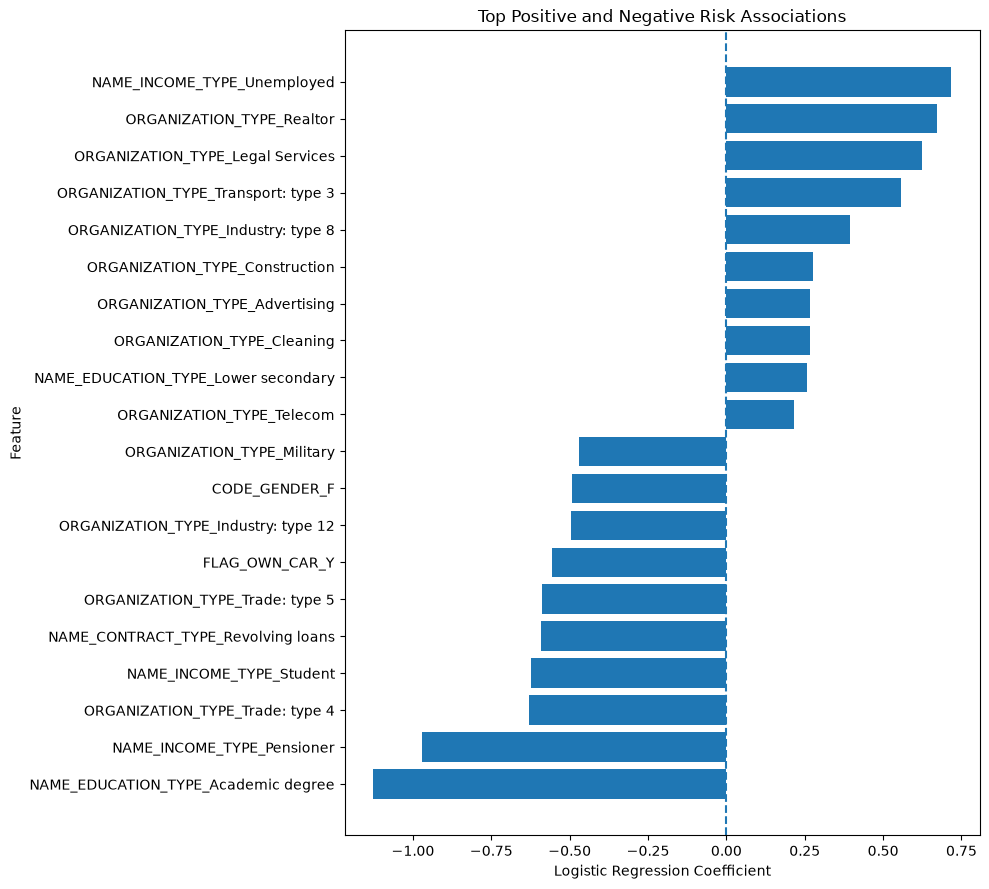

In [66]:
top_coefficient_plot = pd.concat([
    top_negative_coefficients.head(10),
    top_positive_coefficients.head(10),
]).sort_values("coefficient")

plt.figure(figsize=(10, 9))

plt.barh(
    top_coefficient_plot["feature"],
    top_coefficient_plot["coefficient"],
)

plt.axvline(
    x=0,
    linestyle="--",
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title(
    "Top Positive and Negative Risk Associations"
)

plt.tight_layout()
plt.show()

## 12. Coefficient Stability and Category Support

Large categorical coefficients may be driven by categories with limited
sample sizes. Category frequency and observed default rate are reviewed
before coefficients are interpreted as meaningful risk signals.

In [69]:
def get_category_support(
    raw_data: pd.DataFrame,
    target: pd.Series,
    categorical_features: list[str],
) -> pd.DataFrame:
    data = raw_data.copy()
    data["TARGET"] = target

    rows = []

    for feature in categorical_features:
        grouped = (
            data
            .groupby(feature, dropna=False)
            .agg(
                applicants=("TARGET", "size"),
                default_rate=("TARGET", "mean"),
            )
            .reset_index()
        )

        grouped["feature"] = feature
        grouped = grouped.rename(
            columns={feature: "category"}
        )

        rows.append(grouped)

    return pd.concat(
        rows,
        ignore_index=True,
    )

In [71]:
categorical_features = (
    X_train_fe
    .select_dtypes(
        include=["object", "string", "category"]
    )
    .columns
    .tolist()
)

categorical_features

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'ORGANIZATION_TYPE']

In [72]:
category_support = get_category_support(
    raw_data=X_train_fe,
    target=y_train,
    categorical_features=categorical_features,
)

category_support.head()

,category,applicants,default_rate,feature
0,Cash loans,222560,0.083447,NAME_CONTRACT_TYPE
1,Revolving loans,23448,0.054930,NAME_CONTRACT_TYPE
2,F,161887,0.070012,CODE_GENDER
3,M,84119,0.101356,CODE_GENDER
4,XNA,2,0.000000,CODE_GENDER


In [73]:
features_to_review = [
    "NAME_INCOME_TYPE_Unemployed",
    "ORGANIZATION_TYPE_Realtor",
    "ORGANIZATION_TYPE_Legal Services",
    "ORGANIZATION_TYPE_Transport: type 3",
    "ORGANIZATION_TYPE_Industry: type 8",
    "ORGANIZATION_TYPE_Construction",
    "ORGANIZATION_TYPE_Advertising",
    "ORGANIZATION_TYPE_Cleaning",
    "NAME_EDUCATION_TYPE_Lower secondary",
    "ORGANIZATION_TYPE_Telecom",
    "ORGANIZATION_TYPE_Military",
    "CODE_GENDER_F",
    "ORGANIZATION_TYPE_Industry: type 12",
    "FLAG_OWN_CAR_Y",
    "ORGANIZATION_TYPE_Trade: type 5",
    "NAME_CONTRACT_TYPE_Revolving loans",
    "NAME_INCOME_TYPE_Student",
    "ORGANIZATION_TYPE_Trade: type 4",
    "NAME_INCOME_TYPE_Pensioner",
    "NAME_EDUCATION_TYPE_Academic degree",
]

In [74]:
feature_category_map = {
    "NAME_INCOME_TYPE_Unemployed": (
        "NAME_INCOME_TYPE",
        "Unemployed",
    ),
    "ORGANIZATION_TYPE_Realtor": (
        "ORGANIZATION_TYPE",
        "Realtor",
    ),
    "ORGANIZATION_TYPE_Legal Services": (
        "ORGANIZATION_TYPE",
        "Legal Services",
    ),
    "ORGANIZATION_TYPE_Transport: type 3": (
        "ORGANIZATION_TYPE",
        "Transport: type 3",
    ),
    "ORGANIZATION_TYPE_Industry: type 8": (
        "ORGANIZATION_TYPE",
        "Industry: type 8",
    ),
    "ORGANIZATION_TYPE_Construction": (
        "ORGANIZATION_TYPE",
        "Construction",
    ),
    "ORGANIZATION_TYPE_Advertising": (
        "ORGANIZATION_TYPE",
        "Advertising",
    ),
    "ORGANIZATION_TYPE_Cleaning": (
        "ORGANIZATION_TYPE",
        "Cleaning",
    ),
    "NAME_EDUCATION_TYPE_Lower secondary": (
        "NAME_EDUCATION_TYPE",
        "Lower secondary",
    ),
    "ORGANIZATION_TYPE_Telecom": (
        "ORGANIZATION_TYPE",
        "Telecom",
    ),
    "ORGANIZATION_TYPE_Military": (
        "ORGANIZATION_TYPE",
        "Military",
    ),
    "CODE_GENDER_F": (
        "CODE_GENDER",
        "F",
    ),
    "ORGANIZATION_TYPE_Industry: type 12": (
        "ORGANIZATION_TYPE",
        "Industry: type 12",
    ),
    "FLAG_OWN_CAR_Y": (
        "FLAG_OWN_CAR",
        "Y",
    ),
    "ORGANIZATION_TYPE_Trade: type 5": (
        "ORGANIZATION_TYPE",
        "Trade: type 5",
    ),
    "NAME_CONTRACT_TYPE_Revolving loans": (
        "NAME_CONTRACT_TYPE",
        "Revolving loans",
    ),
    "NAME_INCOME_TYPE_Student": (
        "NAME_INCOME_TYPE",
        "Student",
    ),
    "ORGANIZATION_TYPE_Trade: type 4": (
        "ORGANIZATION_TYPE",
        "Trade: type 4",
    ),
    "NAME_INCOME_TYPE_Pensioner": (
        "NAME_INCOME_TYPE",
        "Pensioner",
    ),
    "NAME_EDUCATION_TYPE_Academic degree": (
        "NAME_EDUCATION_TYPE",
        "Academic degree",
    ),
}

In [75]:
review_rows = []

for encoded_feature, (
    original_feature,
    category,
) in feature_category_map.items():

    coefficient_row = coefficient_table[
        coefficient_table["feature"]
        == encoded_feature
    ]

    support_row = category_support[
        (category_support["feature"] == original_feature)
        & (
            category_support["category"].astype(str)
            == str(category)
        )
    ]

    if not coefficient_row.empty and not support_row.empty:
        review_rows.append({
            "encoded_feature": encoded_feature,
            "coefficient": coefficient_row[
                "coefficient"
            ].iloc[0],
            "odds_ratio": coefficient_row[
                "odds_ratio"
            ].iloc[0],
            "applicants": support_row[
                "applicants"
            ].iloc[0],
            "observed_default_rate": support_row[
                "default_rate"
            ].iloc[0],
        })

coefficient_support_review = pd.DataFrame(
    review_rows
)

coefficient_support_review.sort_values(
    by="coefficient",
    ascending=False,
).round(4)

,encoded_feature,coefficient,odds_ratio,applicants,observed_default_rate
0,NAME_INCOME_TYPE_Unemployed,0.7169,2.0481,17,0.2941
1,ORGANIZATION_TYPE_Realtor,0.6733,1.9607,324,0.1142
2,ORGANIZATION_TYPE_Legal Services,0.6238,1.8661,250,0.0840
3,ORGANIZATION_TYPE_Transport: type 3,0.5574,1.7461,964,0.1577
4,ORGANIZATION_TYPE_Industry: type 8,0.3938,1.4826,19,0.1579
5,ORGANIZATION_TYPE_Construction,0.2771,1.3193,5399,0.1195
6,ORGANIZATION_TYPE_Advertising,0.2663,1.3052,331,0.0876
7,ORGANIZATION_TYPE_Cleaning,0.2655,1.3041,212,0.1132
8,NAME_EDUCATION_TYPE_Lower secondary,0.2563,1.2921,3025,0.1107
9,ORGANIZATION_TYPE_Telecom,0.2141,1.2388,452,0.0819


### Coefficient Interpretation Cautions

The largest coefficients are dominated by categorical levels, especially
organization types. These effects must be interpreted together with
category sample size and observed default rate because rare categories may
produce unstable coefficients.

Several coefficient directions are economically plausible:

- unemployment and lower-secondary education are associated with higher
  repayment-difficulty odds,
- pension income and academic education are associated with lower odds,
- and some organization types show substantial positive or negative
  associations.

These are conditional associations rather than causal effects.

All one-hot categories are retained in the current regularized baseline,
so categorical coefficients are not interpreted relative to a single
omitted reference category.

Gender is a potentially sensitive attribute. Its coefficient is reported
for diagnostic purposes only and would require fairness and regulatory
review before any production use.

In [76]:
MIN_CATEGORY_SUPPORT = 500
stable_coefficient_support = (
    coefficient_support_review[
        coefficient_support_review["applicants"]
        >= MIN_CATEGORY_SUPPORT
    ]
    .copy()
)

stable_coefficient_support.sort_values(
    by="coefficient",
    ascending=False,
).round(4)

,encoded_feature,coefficient,odds_ratio,applicants,observed_default_rate
3,ORGANIZATION_TYPE_Transport: type 3,0.5574,1.7461,964,0.1577
5,ORGANIZATION_TYPE_Construction,0.2771,1.3193,5399,0.1195
8,NAME_EDUCATION_TYPE_Lower secondary,0.2563,1.2921,3025,0.1107
10,ORGANIZATION_TYPE_Military,-0.4710,0.6244,2113,0.0492
11,CODE_GENDER_F,-0.4924,0.6112,161887,0.0700
13,FLAG_OWN_CAR_Y,-0.5551,0.5740,83595,0.0727
15,NAME_CONTRACT_TYPE_Revolving loans,-0.5925,0.5529,23448,0.0549
18,NAME_INCOME_TYPE_Pensioner,-0.9696,0.3792,44134,0.0536


In [77]:
stable_positive_categories = (
    stable_coefficient_support[
        stable_coefficient_support["coefficient"] > 0
    ]
    .sort_values(
        by="coefficient",
        ascending=False,
    )
)

stable_negative_categories = (
    stable_coefficient_support[
        stable_coefficient_support["coefficient"] < 0
    ]
    .sort_values(
        by="coefficient",
        ascending=True,
    )
)

display(stable_positive_categories.round(4))
display(stable_negative_categories.round(4))

,encoded_feature,coefficient,odds_ratio,applicants,observed_default_rate
3,ORGANIZATION_TYPE_Transport: type 3,0.5574,1.7461,964,0.1577
5,ORGANIZATION_TYPE_Construction,0.2771,1.3193,5399,0.1195
8,NAME_EDUCATION_TYPE_Lower secondary,0.2563,1.2921,3025,0.1107


,encoded_feature,coefficient,odds_ratio,applicants,observed_default_rate
18,NAME_INCOME_TYPE_Pensioner,-0.9696,0.3792,44134,0.0536
15,NAME_CONTRACT_TYPE_Revolving loans,-0.5925,0.5529,23448,0.0549
13,FLAG_OWN_CAR_Y,-0.5551,0.5740,83595,0.0727
11,CODE_GENDER_F,-0.4924,0.6112,161887,0.0700
10,ORGANIZATION_TYPE_Military,-0.4710,0.6244,2113,0.0492


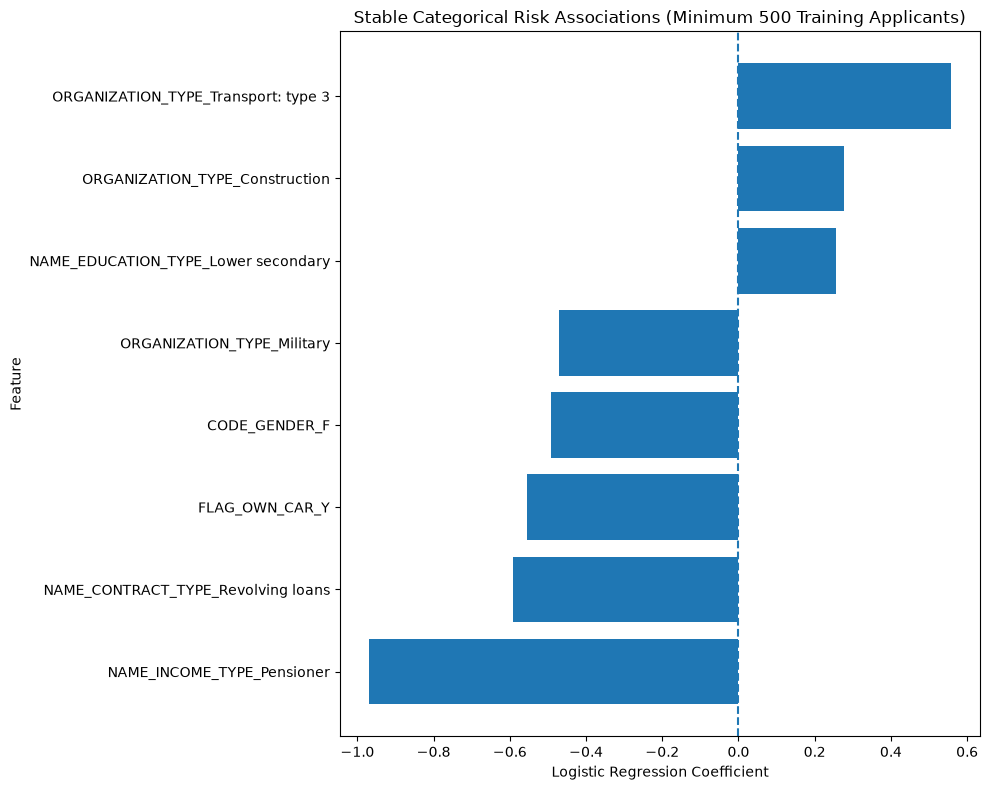

In [78]:
stable_plot_data = pd.concat([
    stable_negative_categories.head(8),
    stable_positive_categories.head(8),
]).sort_values("coefficient")

plt.figure(figsize=(10, 8))

plt.barh(
    stable_plot_data["encoded_feature"],
    stable_plot_data["coefficient"],
)

plt.axvline(
    x=0,
    linestyle="--",
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title(
    "Stable Categorical Risk Associations "
    "(Minimum 500 Training Applicants)"
)

plt.tight_layout()
plt.show()

### Category Support Review

Several of the largest categorical coefficients are associated with rare
categories and should not be treated as stable business drivers.

After requiring at least 500 training applicants per category, the more
stable findings include:

- construction and lower-secondary education are associated with higher
  repayment-difficulty odds;
- pension income, revolving-loan applications, vehicle ownership, and
  military organization types are associated with lower odds.

Rare categories such as unemployed, student, and several specialized
organization types are excluded from the primary interpretation because
their coefficients are based on very limited sample support.

These results describe conditional associations in the fitted model and
should not be interpreted as causal effects.

## 13. Numerical Feature Interpretation

Numerical features were standardized before model training. Therefore,
their coefficients represent the change in log-odds associated with a
one-standard-deviation increase in the feature, holding other variables
constant.

In [80]:
numerical_features = (
    X_train_fe
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)
numerical_coefficient_table = (
    coefficient_table[
        coefficient_table["feature"].isin(
            numerical_features
        )
    ]
    .copy()
    .sort_values(
        by="absolute_coefficient",
        ascending=False,
    )
)

numerical_coefficient_table.round(4)

,feature,coefficient,absolute_coefficient,odds_ratio
11,EXT_SOURCE_3,-0.4023,0.4023,0.6688
25,CREDIT_ANNUITY_RATIO,-0.3292,0.3292,0.7195
30,ANNUITY_GOODS_RATIO,-0.3094,0.3094,0.7339
10,EXT_SOURCE_2,-0.2620,0.2620,0.7695
33,EXT_SOURCE_MIN,-0.2504,0.2504,0.7785
3,AMT_CREDIT,-0.1746,0.1746,0.8398
28,GOODS_CREDIT_RATIO,-0.1639,0.1639,0.8489
8,REGION_RATING_CLIENT_W_CITY,0.1533,0.1533,1.1656
40,TOTAL_MISSING_RATE,-0.1486,0.1486,0.8619
39,TOTAL_MISSING_COUNT,-0.1486,0.1486,0.8619


In [81]:
top_positive_numerical = (
    numerical_coefficient_table[
        numerical_coefficient_table["coefficient"] > 0
    ]
    .sort_values(
        by="coefficient",
        ascending=False,
    )
    .head(12)
)

top_negative_numerical = (
    numerical_coefficient_table[
        numerical_coefficient_table["coefficient"] < 0
    ]
    .sort_values(
        by="coefficient",
        ascending=True,
    )
    .head(12)
)

display(top_positive_numerical.round(4))
display(top_negative_numerical.round(4))

,feature,coefficient,absolute_coefficient,odds_ratio
8,REGION_RATING_CLIENT_W_CITY,0.1533,0.1533,1.1656
18,DAYS_EMPLOYED_SPECIAL_FLAG,0.1423,0.1423,1.1530
34,EXT_SOURCE_MAX,0.1367,0.1367,1.1465
1,CNT_FAM_MEMBERS,0.1299,0.1299,1.1387
29,CREDIT_GOODS_DIFFERENCE,0.1017,0.1017,1.1070
24,ANNUITY_INCOME_RATIO,0.1013,0.1013,1.1067
36,EXT_SOURCE_MISSING_COUNT,0.0912,0.0912,1.0955
5,AMT_GOODS_PRICE,0.0699,0.0699,1.0724
27,CREDIT_PER_PERSON,0.0529,0.0529,1.0543
2,AMT_INCOME_TOTAL,0.0501,0.0501,1.0514


,feature,coefficient,absolute_coefficient,odds_ratio
11,EXT_SOURCE_3,-0.4023,0.4023,0.6688
25,CREDIT_ANNUITY_RATIO,-0.3292,0.3292,0.7195
30,ANNUITY_GOODS_RATIO,-0.3094,0.3094,0.7339
10,EXT_SOURCE_2,-0.2620,0.2620,0.7695
33,EXT_SOURCE_MIN,-0.2504,0.2504,0.7785
3,AMT_CREDIT,-0.1746,0.1746,0.8398
28,GOODS_CREDIT_RATIO,-0.1639,0.1639,0.8489
40,TOTAL_MISSING_RATE,-0.1486,0.1486,0.8619
39,TOTAL_MISSING_COUNT,-0.1486,0.1486,0.8619
9,EXT_SOURCE_1,-0.1478,0.1478,0.8626


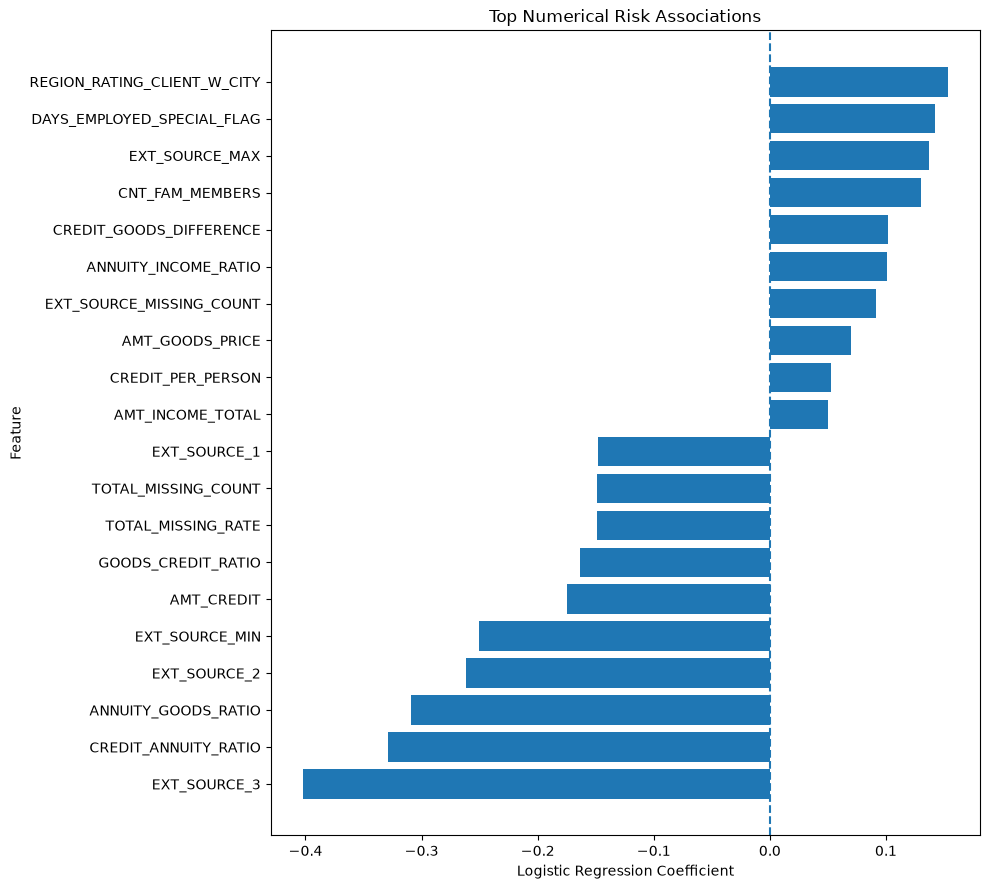

In [82]:
numerical_plot_data = pd.concat([
    top_negative_numerical.head(10),
    top_positive_numerical.head(10),
]).sort_values("coefficient")

plt.figure(figsize=(10, 9))

plt.barh(
    numerical_plot_data["feature"],
    numerical_plot_data["coefficient"],
)

plt.axvline(
    x=0,
    linestyle="--",
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Numerical Risk Associations")

plt.tight_layout()
plt.show()

### Numerical Feature Interpretation

The most reliable numerical relationships are consistent with credit-risk
expectations:

- higher regional risk ratings are associated with greater repayment
  difficulty;
- a higher annuity-to-income ratio is associated with greater
  affordability pressure;
- higher external credit scores are strongly associated with lower risk;
- missing external credit scores are associated with higher risk.

Some raw monetary features and engineered ratios show counterintuitive
individual coefficients because the model includes multiple correlated
representations of the same underlying financial quantities. These
coefficients are therefore not interpreted independently.

`TOTAL_MISSING_COUNT` and `TOTAL_MISSING_RATE` contain duplicate
information, so only one should be retained in a future model refinement.

## 14. Interpretable Logistic Regression

The original predictive baseline contains several correlated raw and
engineered variables. This can make individual coefficients unstable or
counterintuitive.

A reduced logistic regression model is therefore trained using a smaller
set of non-duplicative and business-interpretable numerical features.

The reduced model is used primarily for coefficient interpretation. Its
predictive performance is compared with the full baseline to quantify the
cost of improved interpretability.

In [83]:
INTERPRETABLE_NUMERICAL_FEATURES = [
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "REGION_POPULATION_RELATIVE",
    "REGION_RATING_CLIENT",
    "REGION_RATING_CLIENT_W_CITY",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "REGISTRATION_YEARS",
    "ID_PUBLISH_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "GOODS_CREDIT_RATIO",
    "EMPLOYMENT_AGE_RATIO",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_MISSING_COUNT",
    "BUREAU_INQUIRY_TOTAL",
    "DAYS_EMPLOYED_SPECIAL_FLAG",
    "TOTAL_MISSING_COUNT",
]

INTERPRETABLE_CATEGORICAL_FEATURES = [
    "NAME_CONTRACT_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

In [84]:
interpretable_features = (
    INTERPRETABLE_NUMERICAL_FEATURES
    + INTERPRETABLE_CATEGORICAL_FEATURES
)

missing_interpretable_features = [
    feature
    for feature in interpretable_features
    if feature not in X_train_fe.columns
]

if missing_interpretable_features:
    raise ValueError(
        "Missing interpretable features: "
        f"{missing_interpretable_features}"
    )

print(
    "Interpretable feature count:",
    len(interpretable_features),
)

Interpretable feature count: 29


In [85]:
X_train_interpretable = (
    X_train_fe[interpretable_features]
    .copy()
)

X_test_interpretable = (
    X_test_fe[interpretable_features]
    .copy()
)

print(
    "Interpretable training shape:",
    X_train_interpretable.shape,
)

print(
    "Interpretable test shape:",
    X_test_interpretable.shape,
)

Interpretable training shape: (246008, 29)
Interpretable test shape: (61503, 29)


In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [87]:
interpretable_numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

interpretable_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=True,
            ),
        ),
    ]
)

In [88]:
interpretable_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            interpretable_numerical_pipeline,
            INTERPRETABLE_NUMERICAL_FEATURES,
        ),
        (
            "categorical",
            interpretable_categorical_pipeline,
            INTERPRETABLE_CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

In [89]:
X_train_interpretable_processed = (
    interpretable_preprocessor.fit_transform(
        X_train_interpretable
    )
)

X_test_interpretable_processed = (
    interpretable_preprocessor.transform(
        X_test_interpretable
    )
)

print(
    "Processed interpretable training shape:",
    X_train_interpretable_processed.shape,
)

print(
    "Processed interpretable test shape:",
    X_test_interpretable_processed.shape,
)

Processed interpretable training shape: (246008, 127)
Processed interpretable test shape: (61503, 127)


In [90]:
assert (
    X_train_interpretable_processed.shape[1]
    == X_test_interpretable_processed.shape[1]
)

assert (
    X_train_interpretable_processed.shape[0]
    == len(y_train)
)

assert (
    X_test_interpretable_processed.shape[0]
    == len(y_test)
)

In [91]:
interpretable_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42,
)

interpretable_model.fit(
    X_train_interpretable_processed,
    y_train,
)

/Users/hxxy/Desktop/找工/credit-risk-decisioning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-

In [92]:
interpretable_train_probability = (
    interpretable_model.predict_proba(
        X_train_interpretable_processed
    )[:, 1]
)

interpretable_test_probability = (
    interpretable_model.predict_proba(
        X_test_interpretable_processed
    )[:, 1]
)

In [93]:
interpretable_train_roc_auc = roc_auc_score(
    y_train,
    interpretable_train_probability,
)

interpretable_test_roc_auc = roc_auc_score(
    y_test,
    interpretable_test_probability,
)

interpretable_test_pr_auc = (
    average_precision_score(
        y_test,
        interpretable_test_probability,
    )
)

interpretable_brier_score = (
    brier_score_loss(
        y_test,
        interpretable_test_probability,
    )
)

interpretable_ks = calculate_ks(
    y_test,
    interpretable_test_probability,
)

print(
    "Training ROC-AUC:",
    round(interpretable_train_roc_auc, 4),
)

print(
    "Test ROC-AUC:",
    round(interpretable_test_roc_auc, 4),
)

print(
    "Test PR-AUC:",
    round(interpretable_test_pr_auc, 4),
)

print(
    "Brier Score:",
    round(interpretable_brier_score, 4),
)

print(
    "KS Statistic:",
    round(
        interpretable_ks["ks_statistic"],
        4,
    ),
)

Training ROC-AUC: 0.7455
Test ROC-AUC: 0.7455
Test PR-AUC: 0.2317
Brier Score: 0.0685
KS Statistic: 0.3633


In [94]:
full_vs_interpretable_comparison = pd.DataFrame({
    "Model": [
        "Full Unweighted Baseline",
        "Reduced Interpretable Model",
    ],
    "Train ROC-AUC": [
        unweighted_train_roc_auc,
        interpretable_train_roc_auc,
    ],
    "Test ROC-AUC": [
        unweighted_test_roc_auc,
        interpretable_test_roc_auc,
    ],
    "Test PR-AUC": [
        unweighted_test_pr_auc,
        interpretable_test_pr_auc,
    ],
    "KS Statistic": [
        unweighted_ks["ks_statistic"],
        interpretable_ks["ks_statistic"],
    ],
    "Brier Score": [
        brier_score_loss(
            y_test,
            unweighted_test_probability,
        ),
        interpretable_brier_score,
    ],
})

full_vs_interpretable_comparison.round(4)

,Model,Train ROC-AUC,Test ROC-AUC,Test PR-AUC,KS Statistic,Brier Score
0,Full Unweighted Baseline,0.7500,0.7495,0.2372,0.3727,0.0682
1,Reduced Interpretable Model,0.7455,0.7455,0.2317,0.3633,0.0685


In [95]:
interpretable_feature_names = (
    interpretable_preprocessor
    .get_feature_names_out()
)

clean_interpretable_feature_names = [
    feature_name
    .replace("numerical__", "")
    .replace("categorical__", "")
    for feature_name in interpretable_feature_names
]

assert (
    len(clean_interpretable_feature_names)
    == len(interpretable_model.coef_[0])
)

In [96]:
interpretable_coefficient_table = pd.DataFrame({
    "feature": clean_interpretable_feature_names,
    "coefficient": interpretable_model.coef_[0],
})

interpretable_coefficient_table[
    "absolute_coefficient"
] = (
    interpretable_coefficient_table[
        "coefficient"
    ].abs()
)

interpretable_coefficient_table[
    "odds_ratio"
] = np.exp(
    interpretable_coefficient_table[
        "coefficient"
    ]
)

interpretable_coefficient_table = (
    interpretable_coefficient_table
    .sort_values(
        by="absolute_coefficient",
        ascending=False,
    )
)

interpretable_coefficient_table.head(25).round(4)

,feature,coefficient,absolute_coefficient,odds_ratio
34,NAME_INCOME_TYPE_Pensioner,-1.1656,1.1656,0.3117
36,NAME_INCOME_TYPE_Student,-0.7366,0.7366,0.4788
118,ORGANIZATION_TYPE_Trade: type 5,-0.6673,0.6673,0.5131
117,ORGANIZATION_TYPE_Trade: type 4,-0.6633,0.6633,0.5152
61,OCCUPATION_TYPE_Low-skill Laborers,0.6326,0.6326,1.8826
86,ORGANIZATION_TYPE_Industry: type 12,-0.6269,0.6269,0.5342
41,NAME_EDUCATION_TYPE_Lower secondary,0.6045,0.6045,1.8303
105,ORGANIZATION_TYPE_Realtor,0.5848,0.5848,1.7946
37,NAME_INCOME_TYPE_Unemployed,0.5656,0.5656,1.7604
98,ORGANIZATION_TYPE_Legal Services,0.5588,0.5588,1.7486


In [97]:
interpretable_numerical_coefficients = (
    interpretable_coefficient_table[
        interpretable_coefficient_table[
            "feature"
        ].isin(
            INTERPRETABLE_NUMERICAL_FEATURES
        )
    ]
    .sort_values(
        by="absolute_coefficient",
        ascending=False,
    )
)

interpretable_numerical_coefficients.round(4)

,feature,coefficient,absolute_coefficient,odds_ratio
15,EXT_SOURCE_3,-0.5005,0.5005,0.6062
14,EXT_SOURCE_2,-0.3835,0.3835,0.6814
19,TOTAL_MISSING_COUNT,-0.2607,0.2607,0.7705
13,EXT_SOURCE_1,-0.2139,0.2139,0.8074
11,GOODS_CREDIT_RATIO,-0.1645,0.1645,0.8483
4,REGION_RATING_CLIENT_W_CITY,0.1459,0.1459,1.1571
10,ANNUITY_INCOME_RATIO,0.1414,0.1414,1.1518
18,DAYS_EMPLOYED_SPECIAL_FLAG,0.1370,0.1370,1.1468
6,EMPLOYMENT_YEARS,-0.1008,0.1008,0.9041
1,CNT_FAM_MEMBERS,-0.0942,0.0942,0.9101


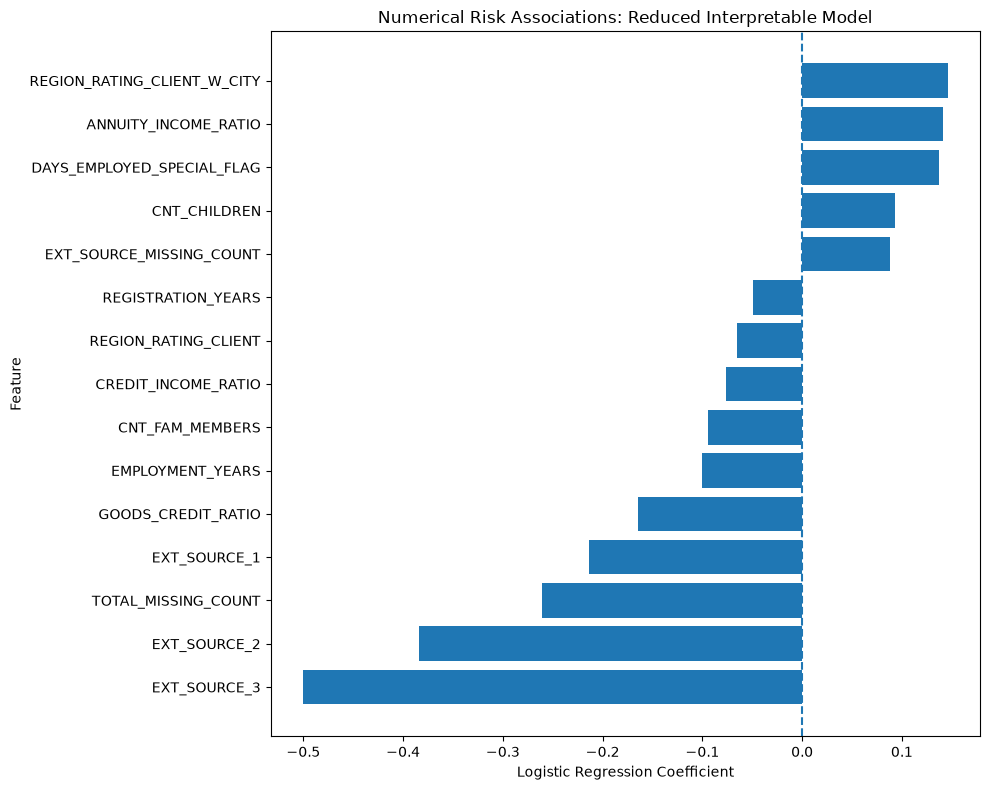

In [98]:
interpretable_numerical_plot = (
    interpretable_numerical_coefficients
    .head(15)
    .sort_values("coefficient")
)

plt.figure(figsize=(10, 8))

plt.barh(
    interpretable_numerical_plot["feature"],
    interpretable_numerical_plot["coefficient"],
)

plt.axvline(
    x=0,
    linestyle="--",
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title(
    "Numerical Risk Associations: "
    "Reduced Interpretable Model"
)

plt.tight_layout()
plt.show()

### Reduced-Model Interpretation

The reduced interpretable model retains most of the predictive performance
of the full baseline:

- Test ROC-AUC decreases by only approximately 0.004
- PR-AUC and KS remain close to the full-model values
- Probability calibration remains nearly unchanged

The most stable numerical associations are:

- higher external credit scores are strongly associated with lower
  repayment-difficulty odds;
- a higher annuity-to-income ratio is associated with greater
  affordability pressure;
- a higher city-level regional risk rating is associated with greater
  risk;
- longer employment history is associated with lower risk;
- missing external credit scores are associated with higher risk.

Some variables remain difficult to interpret independently. In particular,
total missingness, household-size variables, and certain affordability
ratios overlap with other features and may represent conditional or
segment-specific effects rather than simple standalone relationships.

The full model is retained as the primary predictive baseline, while the
reduced model is used for business interpretation.

## 15. Save Baseline Model Artifacts

The full unweighted logistic regression is retained as the primary
probability-of-default baseline because it provides the strongest
predictive performance and substantially better calibration than the
class-weighted model.

The reduced model is saved separately for coefficient interpretation.

In [99]:
BASELINE_MODEL_PATH = (
    MODEL_DIR / "logistic_regression_baseline.joblib"
)

INTERPRETABLE_MODEL_PATH = (
    MODEL_DIR / "logistic_regression_interpretable.joblib"
)

INTERPRETABLE_PREPROCESSOR_PATH = (
    MODEL_DIR / "interpretable_preprocessor.joblib"
)

joblib.dump(
    unweighted_model,
    BASELINE_MODEL_PATH,
)

joblib.dump(
    interpretable_model,
    INTERPRETABLE_MODEL_PATH,
)

joblib.dump(
    interpretable_preprocessor,
    INTERPRETABLE_PREPROCESSOR_PATH,
)

print("Saved baseline model:", BASELINE_MODEL_PATH)
print(
    "Saved interpretable model:",
    INTERPRETABLE_MODEL_PATH,
)
print(
    "Saved interpretable preprocessor:",
    INTERPRETABLE_PREPROCESSOR_PATH,
)

Saved baseline model: /Users/hxxy/Desktop/找工/credit-risk-decisioning/models/logistic_regression_baseline.joblib
Saved interpretable model: /Users/hxxy/Desktop/找工/credit-risk-decisioning/models/logistic_regression_interpretable.joblib
Saved interpretable preprocessor: /Users/hxxy/Desktop/找工/credit-risk-decisioning/models/interpretable_preprocessor.joblib


In [100]:
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_COMPARISON_PATH = (
    REPORTS_DIR / "logistic_regression_model_comparison.csv"
)

RISK_BAND_SUMMARY_PATH = (
    REPORTS_DIR / "logistic_regression_risk_bands.csv"
)

COEFFICIENT_PATH = (
    REPORTS_DIR / "interpretable_model_coefficients.csv"
)

full_vs_interpretable_comparison.to_csv(
    MODEL_COMPARISON_PATH,
    index=False,
)

risk_band_summary.reset_index().to_csv(
    RISK_BAND_SUMMARY_PATH,
    index=False,
)

interpretable_coefficient_table.to_csv(
    COEFFICIENT_PATH,
    index=False,
)

print("Saved:", MODEL_COMPARISON_PATH)
print("Saved:", RISK_BAND_SUMMARY_PATH)
print("Saved:", COEFFICIENT_PATH)

Saved: /Users/hxxy/Desktop/找工/credit-risk-decisioning/reports/logistic_regression_model_comparison.csv
Saved: /Users/hxxy/Desktop/找工/credit-risk-decisioning/reports/logistic_regression_risk_bands.csv
Saved: /Users/hxxy/Desktop/找工/credit-risk-decisioning/reports/interpretable_model_coefficients.csv


## Final Baseline Summary

Three logistic regression configurations were evaluated:

1. Full unweighted logistic regression
2. Full class-weighted logistic regression
3. Reduced interpretable logistic regression

### Predictive performance

The full unweighted model achieved:

- Test ROC-AUC: 0.7495
- Test PR-AUC: 0.2372
- KS statistic: 0.3727
- Brier score: 0.0682

Training and test ROC-AUC were nearly identical, indicating no material
overfitting.

### Class imbalance

At the default 0.50 threshold, the unweighted model identified very few
high-risk applicants. Class weighting increased TARGET=1 recall from
approximately 1% to 68%, but did not materially improve ROC-AUC, PR-AUC,
or KS.

### Calibration

The unweighted model was well calibrated:

- mean predicted default probability: 8.05%
- observed default rate: 8.07%

The balanced model produced a mean score near 42%, so its output should be
used as a ranking score rather than an estimated probability of default.

### Risk segmentation

Using provisional score bands from the balanced model:

- Approve segment: approximately 2.7% observed default rate
- Manual-review segment: approximately 7.3%
- High-risk segment: approximately 20.0%

The high-risk segment contained approximately 21% of applicants while
capturing approximately 53% of repayment-difficulty cases.

### Interpretability

The reduced interpretable model achieved a Test ROC-AUC of 0.7455, only
0.004 below the full baseline.

The strongest stable relationships included:

- higher external credit scores associated with lower risk;
- higher payment burden relative to income associated with higher risk;
- longer employment history associated with lower risk;
- city-level regional risk ratings associated with higher risk.

### Final decision

The full unweighted model is retained as the primary probability baseline.
The class-weighted model is retained as a high-recall screening benchmark.
The reduced model is retained for coefficient and business interpretation.

Operational thresholds remain provisional because final selection should
use validation data, manual-review capacity, and explicit costs of false
approval and false decline.